# Phase 0: 영상 기반 Soft Label 추출

시뮬레이션 영상(train only)에서 frame_0 vs frame_last의 displacement를 측정하여
Knowledge Distillation용 soft label을 생성한다.

- EDA에서 확인: mean_diff AUC = 0.9861 → 영상 displacement가 거의 완벽한 분류기
- 산출물: `data/soft_labels.csv`

In [1]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

DATA_DIR = Path('../data')
train_df = pd.read_csv(DATA_DIR / 'train.csv')
print(f'Train samples: {len(train_df)}')

Train samples: 1000


In [2]:
def compute_displacement(video_path):
    """첫 프레임과 마지막 프레임 간 변위를 다중 지표로 측정"""
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    ret, first = cap.read()
    cap.set(cv2.CAP_PROP_POS_FRAMES, total - 1)
    ret2, last = cap.read()
    cap.release()

    if first is None or last is None:
        return None

    diff = cv2.absdiff(first, last)
    gray_diff = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

    mean_diff = gray_diff.mean()
    changed_ratio = (gray_diff > 20).sum() / gray_diff.size

    # 중간 프레임도 확인 (움직임 시작 시점)
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
    ret3, mid = cap.read()
    cap.release()

    mid_diff = 0.0
    if mid is not None:
        mid_gray = cv2.cvtColor(cv2.absdiff(first, mid), cv2.COLOR_BGR2GRAY)
        mid_diff = mid_gray.mean()

    return {
        'mean_diff': mean_diff,
        'changed_ratio': changed_ratio,
        'mid_diff': mid_diff,
    }

# 전체 train 영상에 대해 displacement 측정
results = []
for sid in tqdm(train_df['id'].tolist(), desc='Computing displacements'):
    vpath = DATA_DIR / 'train' / sid / 'simulation.mp4'
    d = compute_displacement(vpath)
    if d is not None:
        d['id'] = sid
        results.append(d)

disp_df = pd.DataFrame(results).merge(train_df, on='id')
print(f'Computed: {len(disp_df)} / {len(train_df)}')

Computing displacements:   0%|          | 0/1000 [00:00<?, ?it/s]

Computing displacements:   1%|          | 6/1000 [00:00<00:17, 55.23it/s]

Computing displacements:   1%|          | 12/1000 [00:00<00:17, 57.30it/s]

Computing displacements:   2%|▏         | 18/1000 [00:00<00:16, 57.87it/s]

Computing displacements:   2%|▏         | 24/1000 [00:00<00:16, 58.63it/s]

...

Computing displacements:  97%|█████████▋| 974/1000 [00:11<00:00, 94.83it/s]

Computing displacements:  98%|█████████▊| 984/1000 [00:11<00:00, 96.04it/s]

Computing displacements:  99%|█████████▉| 994/1000 [00:11<00:00, 96.82it/s]

Computing displacements: 100%|██████████| 1000/1000 [00:11<00:00, 85.28it/s]

Computed: 1000 / 1000


In [3]:
# Displacement → Soft Probability 변환
# mean_diff 기반 (AUC 0.9861로 가장 판별력 높음)

# 방법: stable/unstable 각각의 mean_diff 분포를 기반으로
# 시그모이드 매핑으로 soft probability 생성

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score

# LogisticRegression으로 최적 매핑 학습
X = disp_df[['mean_diff', 'changed_ratio', 'mid_diff']].values
y = (disp_df['label'] == 'unstable').astype(int).values

lr = LogisticRegression(C=1.0, max_iter=1000)
lr.fit(X, y)

soft_probs = lr.predict_proba(X)  # [:, 0] = stable, [:, 1] = unstable

print(f'Logistic Regression on displacement features:')
print(f'  AUC: {roc_auc_score(y, soft_probs[:, 1]):.4f}')
print(f'  LogLoss: {log_loss(y, soft_probs[:, 1]):.4f}')
print(f'  Accuracy: {(lr.predict(X) == y).mean():.4f}')
print()

# Soft label 분포 확인
print('Soft probability distribution (unstable_prob):')
print(f'  min: {soft_probs[:, 1].min():.4f}')
print(f'  max: {soft_probs[:, 1].max():.4f}')
print(f'  mean: {soft_probs[:, 1].mean():.4f}')
print(f'  std: {soft_probs[:, 1].std():.4f}')
print()

# Hard label과 일치율
hard_pred = (soft_probs[:, 1] > 0.5).astype(int)
agreement = (hard_pred == y).mean()
print(f'Agreement with hard labels: {agreement:.4f}')

# 불일치 샘플 (경계 케이스)
disagree_mask = hard_pred != y
print(f'Disagreement samples: {disagree_mask.sum()}')
if disagree_mask.sum() > 0:
    disagree_df = disp_df[disagree_mask][['id', 'label', 'mean_diff', 'changed_ratio']].copy()
    disagree_df['soft_unstable_prob'] = soft_probs[disagree_mask, 1]
    print(disagree_df.to_string(index=False))

Logistic Regression on displacement features:
  AUC: 0.9862
  LogLoss: 0.1278
  Accuracy: 0.9570

Soft probability distribution (unstable_prob):
  min: 0.0007
  max: 1.0000
  mean: 0.5000
  std: 0.4585

Agreement with hard labels: 0.9570
Disagreement samples: 43
        id    label  mean_diff  changed_ratio  soft_unstable_prob
TRAIN_0006 unstable   2.724799       0.011353            0.013752
TRAIN_0067 unstable   3.754293       0.019701            0.310370
TRAIN_0082   stable   4.018222       0.041267            0.514796
TRAIN_0097 unstable   3.634352       0.027635            0.226368
TRAIN_0107 unstable   3.731364       0.020440            0.294309
TRAIN_0145 unstable   3.217706       0.019335            0.069036
TRAIN_0158 unstable   3.720900       0.020264            0.286714
TRAIN_0174 unstable   2.613749       0.014723            0.009456
TRAIN_0205 unstable   3.530416       0.032864            0.166968
TRAIN_0223 unstable   3.615207       0.032850            0.217615
TRAIN_0240 

In [4]:
# Soft Label CSV 저장
soft_label_df = pd.DataFrame({
    'id': disp_df['id'],
    'hard_label': disp_df['label'],
    'soft_unstable_prob': soft_probs[:, 1],
    'soft_stable_prob': soft_probs[:, 0],
    'mean_diff': disp_df['mean_diff'],
    'changed_ratio': disp_df['changed_ratio'],
})

output_path = DATA_DIR / 'soft_labels.csv'
soft_label_df.to_csv(output_path, index=False)
print(f'Saved: {output_path}')
print(f'Shape: {soft_label_df.shape}')
soft_label_df.head(10)

Saved: ..\data\soft_labels.csv
Shape: (1000, 6)


,id,hard_label,soft_unstable_prob,soft_stable_prob,mean_diff,changed_ratio
0,TRAIN_0001,unstable,0.999301,6.991648e-04,6.143602,0.043545
1,TRAIN_0002,unstable,1.000000,1.620926e-14,13.402649,0.106866
2,TRAIN_0003,unstable,0.839449,1.605513e-01,4.481127,0.027439
3,TRAIN_0004,unstable,0.921818,7.818196e-02,4.722154,0.030918
4,TRAIN_0005,stable,0.000763,9.992369e-01,1.863369,0.003242
5,TRAIN_0006,unstable,0.013752,9.862478e-01,2.724799,0.011353
6,TRAIN_0007,unstable,1.000000,0.000000e+00,16.884447,0.153497
7,TRAIN_0008,unstable,1.000000,1.584510e-12,12.045369,0.105252
8,TRAIN_0009,unstable,0.816474,1.835259e-01,4.433153,0.027201
9,TRAIN_0010,stable,0.008649,9.913509e-01,2.587280,0.013231


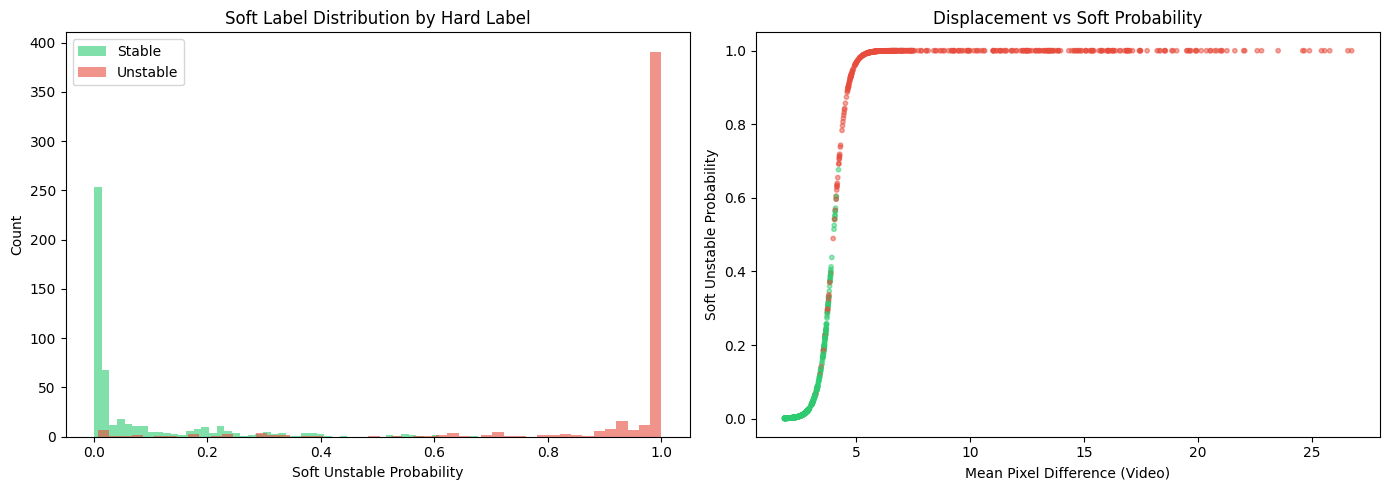

DONE - soft_labels.csv saved. Proceed to 02_train.ipynb


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stable_mask = disp_df['label'] == 'stable'
unstable_mask = disp_df['label'] == 'unstable'

axes[0].hist(soft_probs[stable_mask, 1], bins=50, alpha=0.6, label='Stable', color='#2ecc71')
axes[0].hist(soft_probs[unstable_mask, 1], bins=50, alpha=0.6, label='Unstable', color='#e74c3c')
axes[0].set_xlabel('Soft Unstable Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Soft Label Distribution by Hard Label')
axes[0].legend()

axes[1].scatter(disp_df['mean_diff'], soft_probs[:, 1], 
                c=['#e74c3c' if l == 'unstable' else '#2ecc71' for l in disp_df['label']],
                alpha=0.5, s=10)
axes[1].set_xlabel('Mean Pixel Difference (Video)')
axes[1].set_ylabel('Soft Unstable Probability')
axes[1].set_title('Displacement vs Soft Probability')

plt.tight_layout()
plt.show()

print('DONE - soft_labels.csv saved. Proceed to 02_train.ipynb')